# Speech Command Recognition for Wheelchair Navigation
Project mentor: Ryan Pilgrim

Wesley Tse <wtse5@jh.edu>, Yusoo Hwang <yhwang20@jh.edu>, Jayden Allegakoen <jallega1@jhu.edu>, Vishal Vinjamuri <vvinjam1@jh.edu>

# Git Repo: https://github.com/vvinjam1/Machine_Learning_Final_Model.git

# Outline and Deliverables

### Uncompleted Deliverables
1. Would like to Complete #1: "Optimize the trained model for real-time deployment by reducing inference latency and model size." We tried training a Depthwise Separable ResNet model (DS ResNet) designed to reduce latency and model size. We planned to compare the inference latency of this model to the others but we realized it took longer to train and decided to focus on our current models first.
2. Would like to Complete #2: "Evaluate system performance using live microphone input and test robustness across different speakers and noisy environments." This could be easily done but required our final models to finish training first. With the resources available to use, our models took a lomg time to train and we ran out of time.
3. Would like to Complete #3: "Extend the system by adding custom commands or exploring speaker-specific fine-tuning for improved personalization." To achieve this, we would need access to a lot of custom generated data. We did not have the resources nor time to generate thousands of custom command samples.
4. Must Complete #2: "Train a baseline convolutional neural network (CNN) model for speech command classification using the Google Speech Commands dataset and achieve strong classification performance.": Decided it wasn't worth comparing. We instead focused on the ResNet and ResNet+Transformer.

### Completed Deliverables
1. Must Complete #1: "Develop a complete preprocessing pipeline that converts raw 1-second WAV audio files into normalized log-Mel spectrograms with consistent dimensions.": We discuss our dataset pre-processing [in "Pre-Processing" below](#scrollTo=XN1fYEfGidiD&line=2&uniqifier=1&line=10&uniqifier=1).
2. Must Complete #3: "Evaluate model performance using accuracy and confusion matrices, and analyze common misclassifications on the test set." We discuss model performance and evaluation metrics [in "Results" below](#scrollTo=_Zdp4_H-kx8H&line=5&uniqifier=1).
3. Expect Complete #1: "Compare multiple CNN architectures (e.g., baseline CNN, ResNet, DenseNet) and analyze trade-offs in accuracy and computational complexity." We compare CNN architectures and tradeoffs [in "Results" below](#scrollTo=_Zdp4_H-kx8H&line=5&uniqifier=1).
4. Expect Complete #2: "Apply data augmentation techniques such as time shifting, background noise injection, and gain variation to improve robustness,
and evaluate their impact on performance.": We discuss our dataset augmentation [in "Pre-Processing" below](#scrollTo=XN1fYEfGidiD&line=2&uniqifier=1&line=30&uniqifier=1).
5. Expect Complete #3: "Develop a prototype system that maps predicted speech commands to actions (e.g., wheelchair navigation or game controls) and demonstrate real-time inference." We discuss and provide a run through of our gaming system prototype [in "Results" below](#scrollTo=_Zdp4_H-kx8H&line=5&uniqifier=1).


### Additional Deliverables
1. We created a sequential audio dataset by combining two of the 1 sec audio files into 1 and trained the models under this idea. The Reasoning is found [in  "Motivation for Sequencing" below](#scrollTo=PqB48IF9kMBf&line=5&uniqifier=1).


# Preliminaries

## What problem were you trying to solve or understand?


### Real-World Impact
As presented in our project proposal, traditional human-machine interaction (HMI) is restricted to physical controls and interfaces that often pose as barriers to individuals with impaired motor function. We specifically aim to offer a voice-controlled alternative for wheelchair navigation and adaptive gaming applications. The task at hand is to implement keyword spotting (KWS) for voice command recognition. The real-world implication is the restoration of a sense of autonomy and social inclusion for these individuals.

### A Unique Problem
What makes this problem unique from other KWS applications is the required level of scrutinty in ensuring commands are correctly identified. Speech command recognition for wheelchair navigation can considered as a safety-critical system. In contrast, the majority of KWS applications is for the matter of convenience and therefore serve in low-stakes situations. Examples of such uses include smart speakers, voice assistants, and smart home devices. If a command is misclassified in these environments, the consequences are trivial. However, for wheelchair navigation, KWS operates in high-stakes situations where a misclassified or delayed command is a safety risk and can result in physical injury to the user and possibly those around them. For example, misclassification of "right" as "left" or "stop" as "go" in busy spaces could cause a collision.

### Ethical Implications
From an ethical perspective, this project must confront issues of model bias, privacy, and responsibility. Different people speak in different ways. This includes diverse accents, pitches, rhythms, and volumes. There are also regional variations observed when individuals prefer and use different words for the same thing. Additionally, users with speech impairments may sound drastically different from healthy speakers. Training models solely on "standard" speech creates model bias, which limits the diversity of speech profiles that can be classified with the models. Privacy is another concern as the wheelchair will always be listening for the user's next command. Protection of private conversations and daily dialogue is important and can be achieved through localized KWS, preventing data upload to the cloud. Lastly, discussion on accountability for failure events is needed. If an accident occurs due to a misclassified command, who takes responsibilty? Is the model and developer always at fault? Does the user ever take the blame for how they speak? What if the model acts on commands spoken by nearby nonusers? These are all implications that require further deliberation to ensure the application is ethcically acceptable.

## Dataset(s)



We used the [Google Speech Commands dataset](https://www.kaggle.com/datasets/yashdogra/speech-commands/data) (version 2) which consists of 105,800 labeled 1-second audio recordings of 35 different spoken English words.  The recordings are organized in folders with names identifying the corresponding word label. Each audio file is named by a random ID that corresponds to a particular speaker. The data is presented as WAV files each sampled at 16kHz. Recordings were collected through crowdsourcing via a Google AIY project. Volunteer contributors recorded themselves speaking single words, with most contributors making multiple recordings of each word. Because of this, the speakers, recordings, and environemnts in which they were recorded are diverse.

We chose this dataset for many reasons. First, it includes specific commands that are relevant and neccessary for our navigation application, such as "left," "right," "forward," "backward," "go," and "stop."  Second, the data represents a diverse range of speakers with varying accents, pitches, and talking speed. Training on this diversity helps ensure that our wheelchair nvaigation model will effectively respond to a wide range of users. Additionally, the dataset includes non-command words as well as a folder of background noise audio files. These help distinguish commands from regular conversation and ambient sounds, which is critical for safe navigation in noisy and public spaces.

For the commands we were interested in, here are the following number of examples for each category: <br>

* 'yes': 4044 files <br>
* 'no': 3941 files <br>
* 'up': 3723 files <br>
* 'down': 3917 files <br>
* 'left': 3801 files <br>
* 'right': 3778 files <br>
* 'on': 3845 files <br>
* 'off': 3745 files <br>
* 'stop': 3872 files <br>
* 'go': 3880 files <br>

For background noise, there are 7 files.

### 3 command examples from the dataset

In [ ]:
import kagglehub
import os
import random
import librosa
import IPython.display as ipd

# Download latest version
path = kagglehub.dataset_download("yashdogra/speech-commands")
dataset_path = path

# Define the target commands
selected_examples = ['stop', 'no', 'right']

# Specific files to show
specific_filenames = {
    'stop': '5f5eef60_nohash_4.wav',
    'no': '070b49af_nohash_1.wav',
    'right': '37fc5d97_nohash_0.wav'
}

selected_files = []

for cmd in selected_examples:
    cmd_dir = os.path.join(dataset_path, cmd)

# Check if folder exists
    if not os.path.exists(cmd_dir):
        print(f"Warning: Folder for '{cmd}' not found.")
        continue

    # Determine which file to use
    target_file = specific_filenames.get(cmd)

    if target_file and os.path.exists(os.path.join(cmd_dir, target_file)):
        file_name = target_file
    else:
        # Pick the first .wav file in that folder
        all_files = [f for f in os.listdir(cmd_dir) if f.endswith('.wav')]
        file_name = all_files[0] if all_files else None

    if file_name:
        file_path = os.path.join(cmd_dir, file_name)
        selected_files.append(file_path)

        print(f"COMMAND:  {cmd.upper()}")
        print(f"FILENAME: {file_name}")

        # Display audio
        display(ipd.Audio(file_path))
        print("-" * 40)

Using Colab cache for faster access to the 'speech-commands' dataset.
COMMAND:  STOP
FILENAME: 5f5eef60_nohash_4.wav


----------------------------------------
COMMAND:  NO
FILENAME: 070b49af_nohash_1.wav


----------------------------------------
COMMAND:  RIGHT
FILENAME: 37fc5d97_nohash_0.wav


----------------------------------------


## Pre-processing


### Feature Choice
The primary feature we use is the log-Mel spectrogram, extracted from each 1-second audio waveform using librosa. Specifically, we compute a Mel spectrogram with 128 Mel frequency bands (N_MELS = 128), an FFT window size of 2048 (N_FFT = 2048), and a hop length of 160 samples (HOP_LENGTH = 160), then convert it to the decibel (dB) scale using librosa.power_to_db. This produces a 2D time-frequency representation of shape (128, 101) per sample, which serves as the input to our neural networks.


We chose Mel spectrograms because they capture the frequency content of speech in a way that aligns with human auditory perception — the Mel scale compresses higher frequencies where speech carries less discriminative information. The log (dB) conversion further compresses the dynamic range, making the representation easier for neural networks to learn from. Raw waveforms were retained separately for potential use in preprocessing pipelines but were not fed directly into the models, as spectrograms are both more compact and more informative for this classification task. We also chose not to use other common audio features such as MFCCs (Mel-Frequency Cepstral Coefficients) or chroma features, as log-Mel spectrograms have been shown to be effective for speech command recognition and provide richer frequency information than MFCCs alone.

### Class-Balance

As discussed in the Dataset section above, the 1-second recordings are categorically labeled with words. We encode each command label as well as the background noise class to a specific integer so that the following neural networks can mathematically operate on them. In our data configuration, we can make our dataset class-balanced using a max_samples_per_class paramater that allows us to fix how many samples from each class is included. The number of total samples in each class ranges between around 3700 to 4000 samples. We first tried training our models usingall the samples to maintain maximal speech diversity and found that the existing class imbalance did produce significant bias towards the majority classes. Therefore, our current models are not trained on class-balanced data. That being said, future work could implement class-balance and analyze whether reducing bias or preserving data size and diveristy is more beneficial.

### Missing Data & Outliers

In this context, missing data can be defined as  files that are corrupted, silent, or in the wrong format. We addressed this issue with a try-except block. For every sample, the code will first try to locate and preprocess the file, extract the Mel Spectrogram, and add it to the training dataset. If any of these steps fail, the code will move on to the "except" block which catches the failure without crashing the program, and continues to the next file. The "missing data" file is excluded from the training set.

For the speech data, outliers can be presented as recordings that are longer or shorter than the uniform 1-second duration and as audio that is too loud or quiet. To deal with outliers with temporal deviations, we run every sample through a pad_or_trim function to ensure that all recordings have the same length of duration. This is required for batch processing in neural networks. If the audio is shorter than 1-second, it is padded with zeros that represent silence. If it is longer 1-second, it is trimmed down to the desired length.

To deal with amplitude outliers, we apply Min-Max Normalization, rescaling the original waveform to an amplitude range between [-1, 1]. This standardizes the volume level across all audio files and helps with generalization across different recording environments as the model will learn the shape rather than the amplitude of the recording.



### Data Augmentation

All models share a common base preprocessing pipeline before diverging based on whether they are trained on isolated single commands or sequential multi-command audio.

*Shared Base Pipeline*

After loading each .wav file with librosa at 16 kHz, every audio sample passes through three steps: (1) pad_or_trim to enforce a uniform 1-second length, (2) per-sample Min-Max normalization to [-1, 1], and (3) log-Mel spectrogram extraction. Labels are integer-encoded using scikit-learn's LabelEncoder. The full dataset is then split into training (74%), validation (11%), and test (15%) sets using stratified splitting to preserve class proportions across all splits. To prevent data leakage, spectrogram standardization — zero-centering and scaling by standard deviation — is computed exclusively from the training set and applied to validation and test sets using those same statistics.

*Method 1: Single-Command Training*

In the single-command training setup (ResNet and ResNet-Transformer baseline models), each sample is one isolated 1-second command. During training, augmentation is applied on-the-fly via a custom data generator: each sample has a 50% chance of having a background noise clip mixed in at 10 dB SNR, and independently a 50% chance of receiving SpecAugment masking on its spectrogram. Augmentation is only applied during training, not at validation or test time, so evaluation reflects real-world unaugmented audio.

*Method 2: Sequential Multi-Command Training*

The sequencing models (ResNet-sequencing and ResNet-Transformer-sequencing) are additionally trained on synthetically generated multi-command audio. Using create_sequential_dataset, two audio clips are randomly drawn from the training pool, separated by a 200ms silence gap, concatenated into a single waveform (~2.4 seconds), and re-normalized. This produces samples with multi-label targets containing the two corresponding class integers. We generate 8,000 sequential samples for training, and 1,500 each for validation and test. These sequences go through the same spectrogram extraction pipeline as single-command samples, but are standardized using statistics computed separately from the sequential data, since the concatenated waveforms have a different amplitude and frequency distribution. During training, each batch is drawn from a 50/50 mix of single-command and sequential samples via the CombinedCommandGenerator, with identical noise-mixing and SpecAugment augmentations applied to both types. This approach teaches the model to recognize commands issued back-to-back in continuous audio, rather than only isolated utterances.

###Features
Our pipeline involves both types. The input features — log-Mel spectrograms — are continuous: each element is a real-valued dB measurement representing energy in a frequency band at a point in time. These are treated as continuous floating-point tensors and fed directly into the neural network after standardization (zero mean, unit variance computed from the training set).
The target labels are categorical: each sample belongs to one of 11 discrete classes (10 spoken commands plus a background noise class). We encode these using LabelEncoder, which maps each string label to a unique integer. For the output layer, the network produces a softmax probability distribution over all 11 classes, and the predicted class is taken as the argmax. This is the standard treatment for multi-class classification — unlike continuous regression targets, categorical labels are never ordered or interpolated; they are always treated as discrete, mutually exclusive identities.

In [ ]:
# https://github.com/vvinjam1/Machine_Learning_Final_Model.git

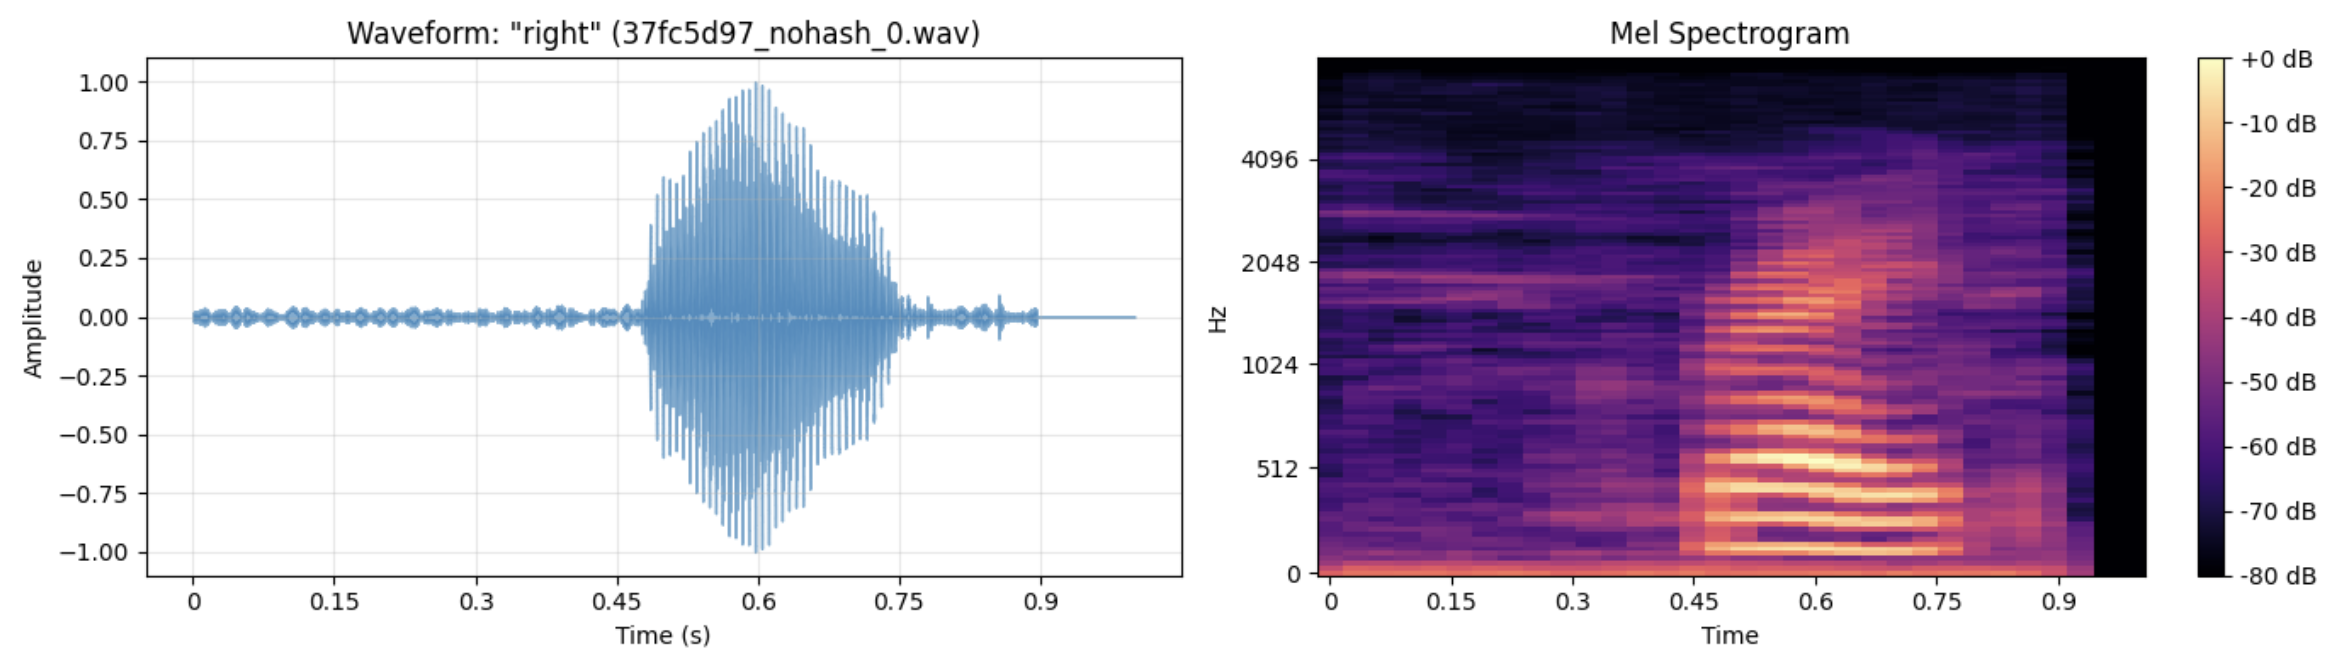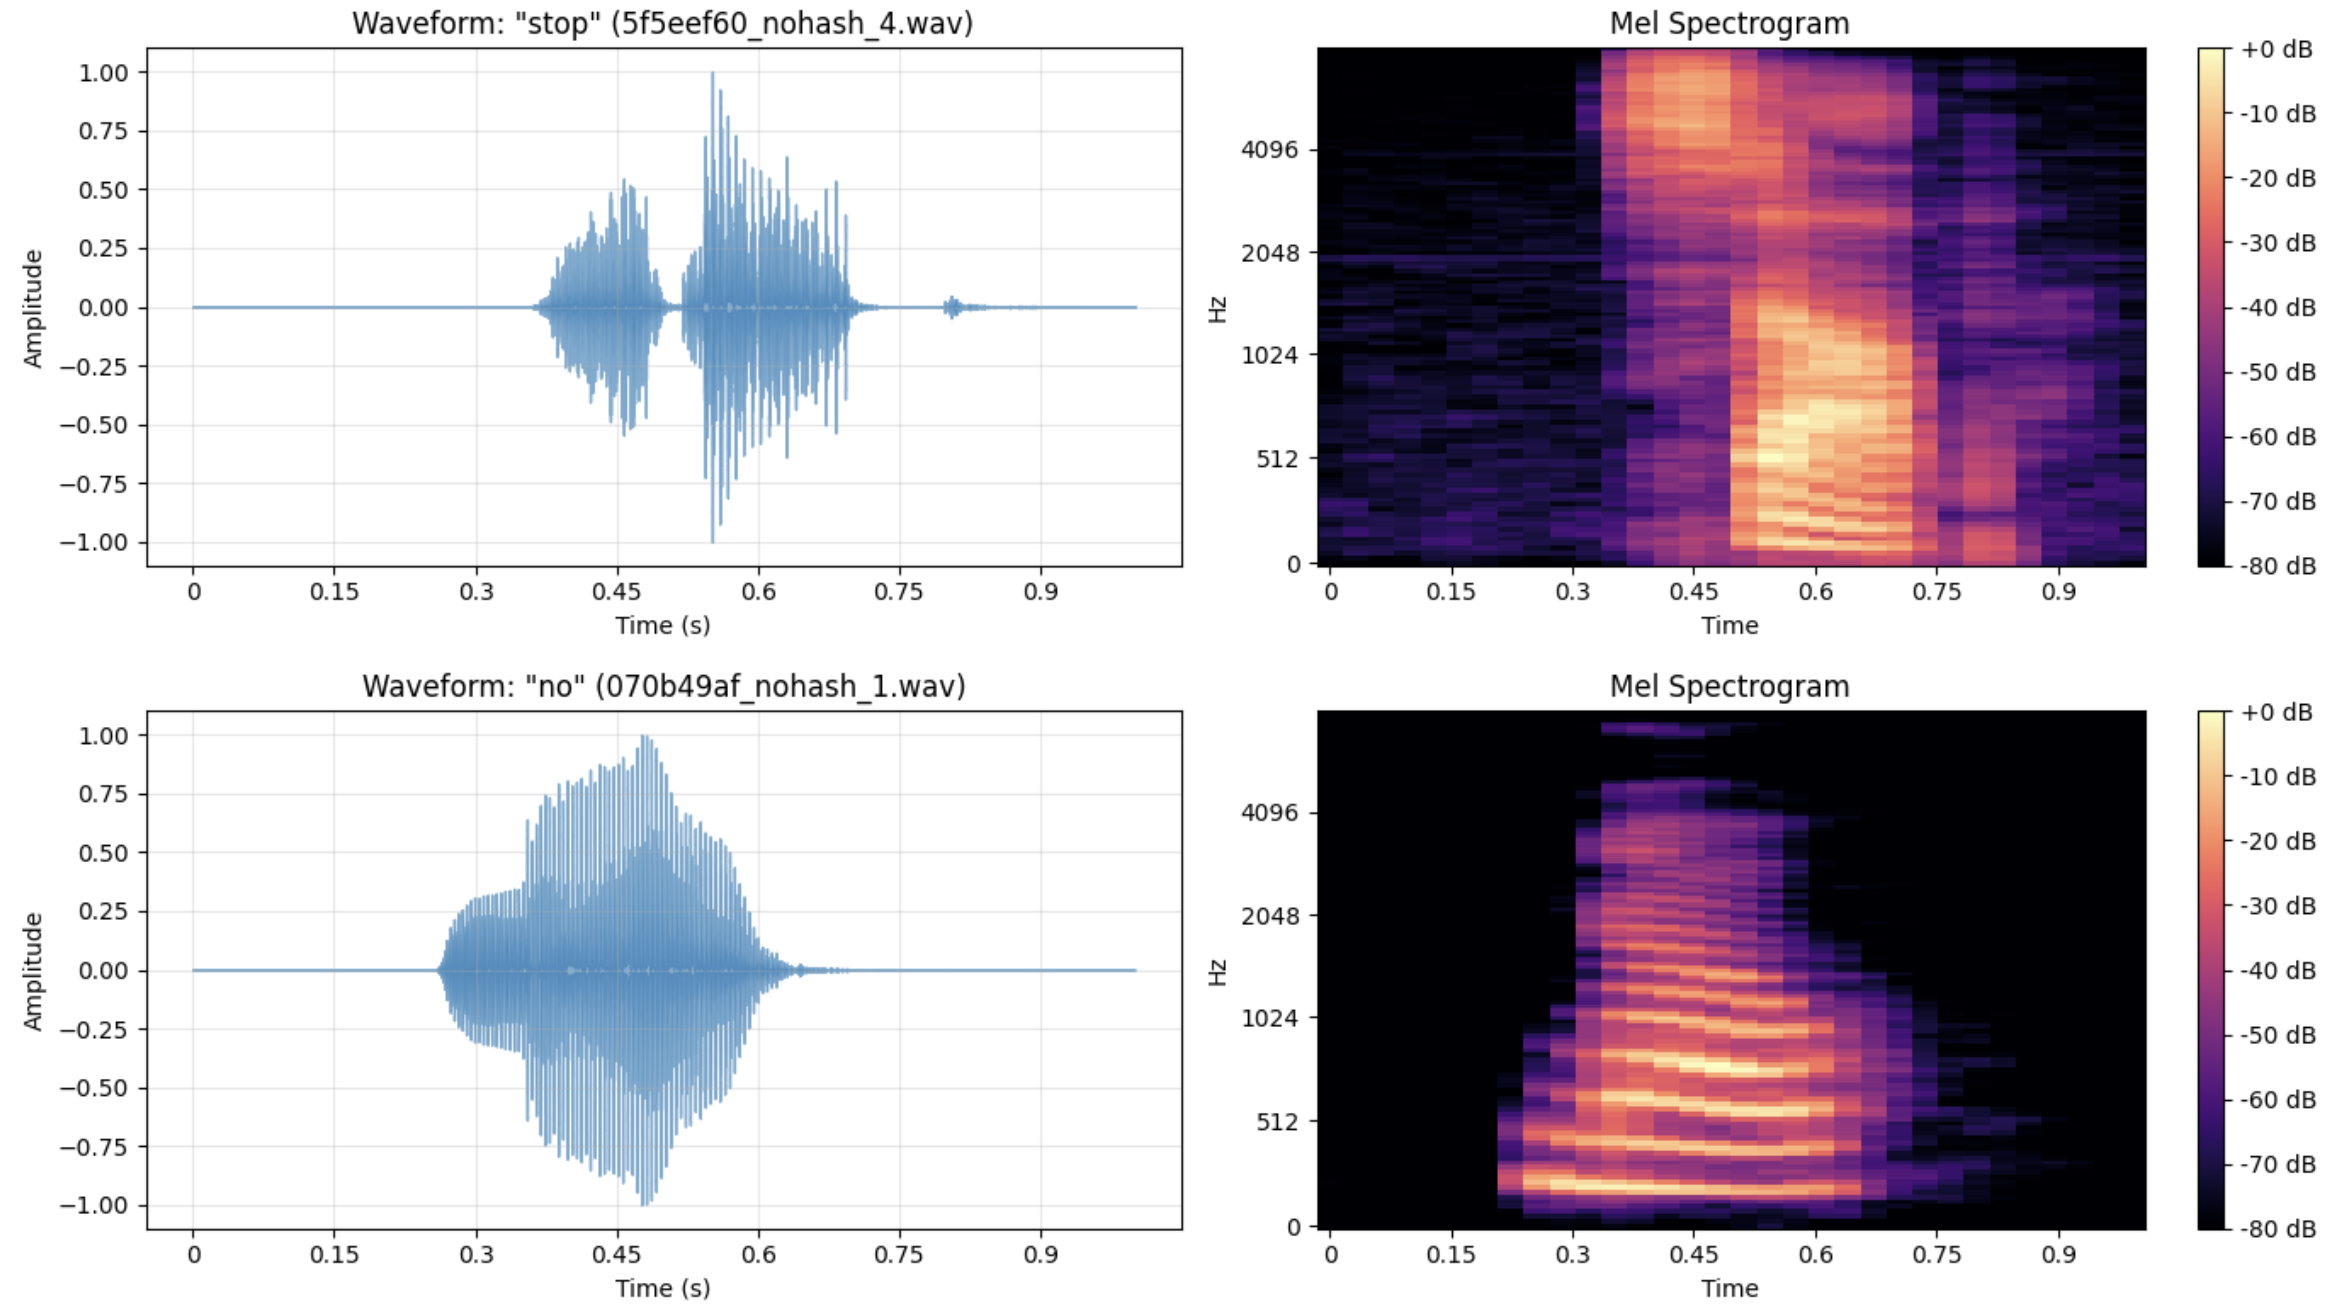

# Models and Evaluation

## Experimental Setup


###Evaluation Methods
All models are evaluated primarily on per-class accuracy and a full classification report (precision, recall, and F1-score per class) on the held-out test set, alongside a confusion matrix to visualize which commands are being misclassified and as what. During training, validation accuracy is monitored each epoch as the early stopping and model checkpoint criterion.

These are reasonable metrics for this task. The primary goal is correctly identifying which spoken command was issued, and top-1 accuracy directly captures that. The per-class classification report adds nuance — in a voice command interface, errors are not symmetric, so knowing whether the model is failing to detect a specific command (low recall) versus frequently mis-predicting noise as a command (low precision) matters for practical use. The confusion matrix further reveals systematic confusions between acoustically similar commands (e.g., "no" vs. "go"). For the sequencing models specifically, we report three separate accuracy values: single-command accuracy, per-command accuracy for each position in the sequence, and full sequence accuracy (the fraction of test sequences where both commands are correctly predicted), which is a stricter joint metric that better reflects real multi-command recognition performance.

In addition to quantitative evaluation on the held-out test set, we conducted live user testing through a custom-built maze game. In this demo, a user speaks directional commands ("up," "down," "left," "right") into a microphone in real time, with "stop" and "go" used to pause and resume the game. The model's predictions directly control the player's movement, making errors immediately visible and intuitive to the user. This form of evaluation complements the quantitative metrics by capturing real-world usability factors that do not appear in a classification report — such as latency, robustness to different speakers and microphone conditions, and how disruptive misclassifications feel in practice. While this evaluation produces no formal metric, it serves as a qualitative stress test of whether the model is actually usable in a realistic interactive environment, which is ultimately the goal of a voice command system.

###Loss Function
The choice of loss function differs between the two training methods. For the single-command models (CNN-Transformer baseline and the single-command head of the sequencing models), we use standard sparse categorical cross-entropy, which is the natural choice for multi-class classification with integer-encoded labels. It measures how well the model's predicted softmax distribution matches the true class, and its log-probability formulation penalizes confident wrong predictions heavily.


For the sequencing models, which produce three output heads (one single-command head and two sequential command heads), we use a custom masked sparse categorical cross-entropy loss. This custom loss applies a binary mask that ignores positions where the label is -1, which is used as a padding sentinel for samples that don't have a second command (i.e., single-command samples passed through the sequential heads). Without masking, the loss would incorrectly penalize the model on those positions. All three heads are weighted equally with loss weights of 1.0, so the total loss is their sum.


We did not experiment with alternative loss functions such as label smoothing or focal loss. Given that the task is relatively clean multi-class classification and our primary issue was generalization (addressed through augmentation) rather than extreme class imbalance, standard cross-entropy was a well-motivated starting point and our resources were better spent exploring architecture and augmentation choices.

###Data Split
The dataset is split into three parts: approximately 74% for training, 11% for validation, and 15% for test. This is done in two stratified stages using scikit-learn's train_test_split: first 15% is reserved as the test set, then 12% of the remaining data is reserved as the validation set. Stratified splitting is used at both stages to ensure that the class proportions in each split closely mirror those in the full dataset, which is especially important since we are not using a class-balanced dataset.


We use three-way splitting rather than a simple train/test split because the validation set serves a distinct purpose from the test set: it is used during training to monitor generalization, inform early stopping, and select the best model checkpoint, which means it influences training decisions. Using the same data for this and final evaluation would produce an optimistic test result. The test set remains completely held out until final evaluation, giving an unbiased estimate of how the model performs on unseen data. The 15% test proportion is large enough to give stable performance estimates across 11 classes.

## Baselines


###Baseline
We compare our ResNet and ResNet+Transformer models against each other across both the single-command and sequencing tasks. Rather than implementing a separate plain CNN baseline, we treat the ResNet (single-command) as the reference point — it is the simplest of our full models and establishes a strong upper bound for isolated command recognition. The ResNet+Transformer is then compared against it to measure whether the added Transformer complexity yields meaningful gains. For the sequencing task, the two sequencing models are compared against each other to evaluate the trade-off between single-command head accuracy and full sequence accuracy.
This is a reasonable comparison because both models are trained under identical conditions — same dataset, same loss functions, same augmentation pipeline, same training schedule — so any performance difference is attributable solely to the backbone architecture.

###Other Methods or Baselines
Yes. The Google Speech Commands dataset is a well-studied benchmark. Prior work includes the original dataset paper by Warden (2018), which reported baseline results using a simple CNN and LSTM. More recent work has demonstrated that attention-based architectures and Transformer models substantially improve over pure CNN baselines, with top-performing systems on the full 35-class version of the dataset reaching accuracies in the high 90s. Our task uses a 10-command subset plus a background noise class (11 classes total), which is a simpler version of the full benchmark, so we would expect higher absolute accuracy. The SpecAugment technique we use was itself validated on speech recognition benchmarks and has been shown to be one of the most effective and computationally cheap augmentation strategies for audio.

## Methods


###Models
We implemented four models across 2 architectural families:

**ResNet-18** — A 18-layer residual network where each residual block applies two 3×3 convolutions with a skip connection, and SE blocks are inserted after the deeper stages to recalibrate channel importance. Residual connections address the vanishing gradient problem that makes deep plain CNNs difficult to train, and SE blocks add a lightweight form of channel-wise attention that helps the model focus on the most informative frequency bands at each layer.


**ResNet+Transformer**— A hybrid architecture where the ResNet-style convolutional stem extracts local spatial features from the spectrogram, and a patch-based Transformer encoder then processes those features globally. The convolutional features are projected into patch embeddings via a 2×2 strided convolution, flattened into a sequence of tokens, and passed through 4 Transformer encoder blocks with multi-head self-attention (4 heads, dimension 256) and feed-forward layers. This hybrid approach leverages CNNs for local feature extraction and the Transformer's self-attention for modeling long-range dependencies across both time and frequency in the spectrogram.


Both architectures were also extended to the sequencing task, adding two additional output heads to the shared backbone (one per command position in the sequence).


We chose these two architectures because they represent complementary design philosophies: the ResNet is a strong, well-understood inductive-bias-heavy approach, while the ResNet+Transformer hybrid incorporates global context through attention. Comparing them on the same data reveals whether the additional capacity and complexity of the Transformer encoder provides measurable gains for this task.

###Motivation for Sequencing


After training the single-command ResNet and ResNet+Transformer models, both achieved very high accuracy even when evaluated on noise-augmented data, suggesting that isolated single-word command recognition had become a near-solved problem for these architectures on this dataset. To create a more meaningful and challenging evaluation, we extended both models to the sequential multi-command task. Recognizing two back-to-back commands in a single continuous audio clip is substantially harder — the model must localize and identify two overlapping temporal regions rather than classify a single isolated utterance, and the added silence gap and concatenation introduce distributional shifts that single-command training does not expose the model to. This extension also better reflects real-world use cases, where a user might issue multiple commands in quick succession rather than one at a time.

###Training Methods
All models are trained using the Adam optimizer with a cosine decay learning rate schedule with linear warmup. The schedule linearly ramps the learning rate from 0 to 1e-3 over the first 5 epochs, then smoothly decays it to a minimum of 1e-6 using a cosine curve. This warmup prevents instability early in training when gradients are large and weights are randomly initialized. Training runs for up to 100 epochs with a batch size of 32, but EarlyStopping with a patience of 15 epochs halts training if validation accuracy does not improve, and restore_best_weights=True ensures the saved model corresponds to the best checkpoint rather than the final epoch. The best checkpoint is also saved explicitly to Google Drive via ModelCheckpoint so it persists beyond the Colab session. Augmentation — noise mixing and SpecAugment — is applied on-the-fly during training only, never at validation or test time, so evaluation reflects real-world unaugmented audio. Evaluation is reported on the held-out test set using accuracy, per-class precision, recall, F1-score, and confusion matrices as described above. For the sequencing models, evaluation additionally reports per-head accuracy and full sequence accuracy.

###Which Methods Were Easy vs Difficult

The single-command ResNet was similarly straightforward. Residual networks are well-documented and Keras provides all the necessary building blocks. The addition of SE blocks added minimal complexity and training was reliable.


The CNN-Transformer was moderately more difficult. The main implementation challenge was the patch embedding step, which requires reshaping the output of the convolutional backbone into a sequence of tokens before passing it to the Transformer encoder. This reshape depends on fully static spatial dimensions, which meant the model had to be built with a fixed input shape rather than a dynamic one — a constraint that caused serialization issues when saving and reloading the model due to a Lambda layer with no explicit output shape. This was the most significant technical difficulty encountered across all models.


The sequencing models introduced the greatest implementation complexity. The multi-output architecture with three heads required a custom CombinedCommandGenerator that draws from both single-command and sequential data pools within each batch, applies different normalization statistics to each pool, and formats labels for all three output heads simultaneously. The masked loss function also required custom implementation to correctly ignore the -1 padding sentinel used for missing labels. Training the sequencing models was noisier since the model simultaneously optimizes three losses, and the mixed-batch generator initially had a bug where single-command spectrograms (101 time frames) and sequential spectrograms (~201 time frames) were being padded to a variable max length per batch, causing inconsistent input shapes that severely degraded training — all models were stuck near 49% accuracy until this was identified and fixed by pre-padding all spectrograms to a fixed T_MAX before training.

###Hyperparameters

Across all models the shared hyperparameters are: peak learning rate (1e-3), minimum learning rate (1e-6), warmup duration (5 epochs), batch size (32), maximum epochs (100), and early stopping patience (15 epochs). Dropout rates were set progressively through the convolutional stages (0.10 → 0.30) with more aggressive dropout (0.5 then 0.3) before the final dense layers. L2 regularization with weight 1e-4 was applied throughout. For the CNN-Transformer, the Transformer depth (4 blocks), number of attention heads (4), embedding dimension (256), and feedforward dimension (512) were fixed based on model capacity appropriate to the task size. For data augmentation, the noise mixing probability (50%), SNR (10 dB), and SpecAugment parameters (up to 15 frequency bands and 20 time frames masked) were fixed. For the sequencing models, the silence gap (200ms) and 50/50 train batch split between single and sequential samples were fixed design choices.


We did not conduct a formal grid search across all combinations due to compute constraints — each training run takes roughly 2–3 hours on a Colab GPU. Instead, hyperparameters were set based on established defaults from the literature for similar tasks and kept fixed across runs to enable fair comparison between architectures. In preliminary testing, the settings most sensitive to performance were the learning rate schedule and dropout. Training without warmup caused unstable early epochs with large gradient updates, visibly hurting final accuracy. Dropout set too high caused underfitting where validation accuracy plateaued well below training potential, while too little dropout led to clear overfitting with a large train/val gap. The patience of 15 epochs was chosen to give the model sufficient time to recover from temporary plateaus without wasting compute on runs that had clearly converged.

In [ ]:
# To see the code for training models, please refer to our git repository
# https://github.com/vvinjam1/Machine_Learning_Final_Model.git

### Plots of Model Performance During Training

ResNet with Noise Mixing

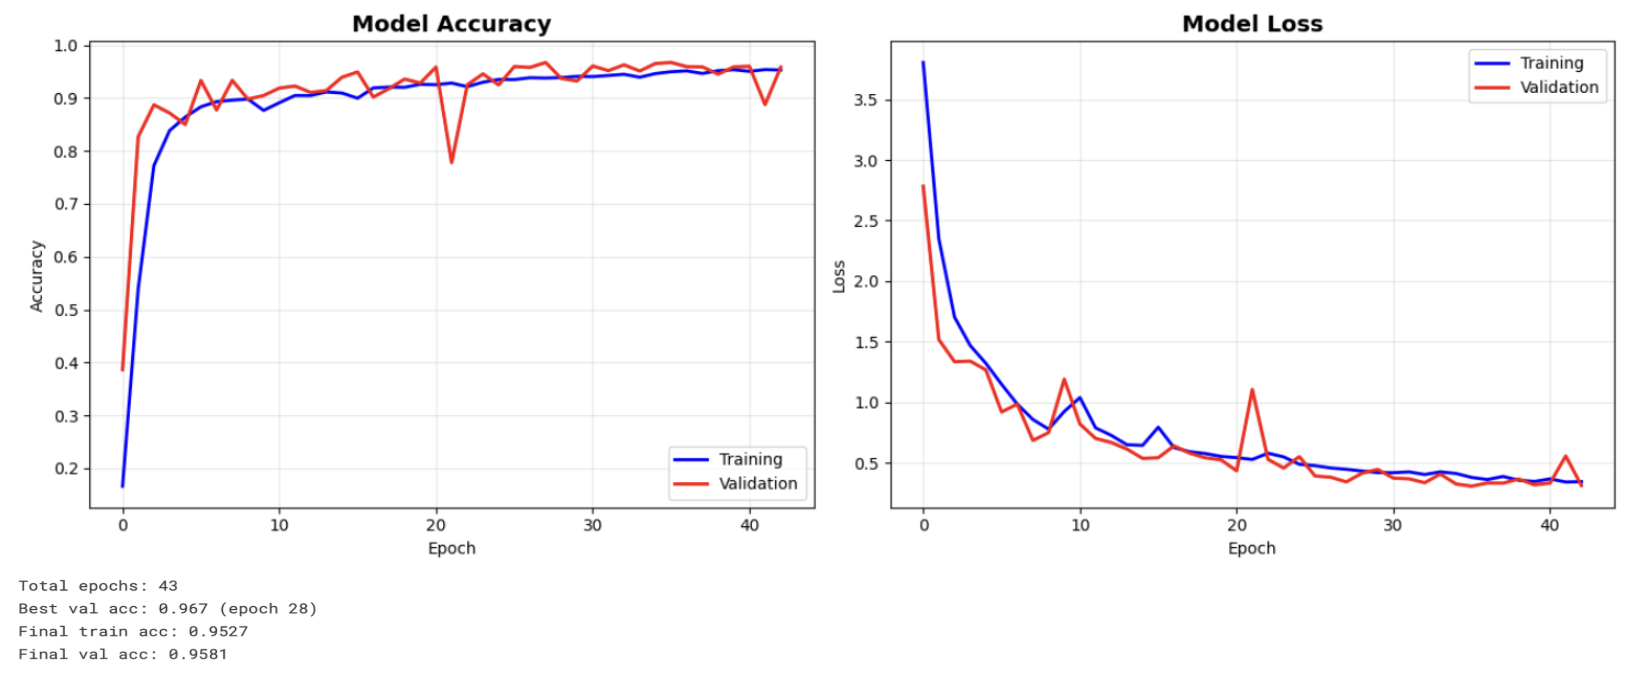

ResNet with Sequencing and Noise Mixing
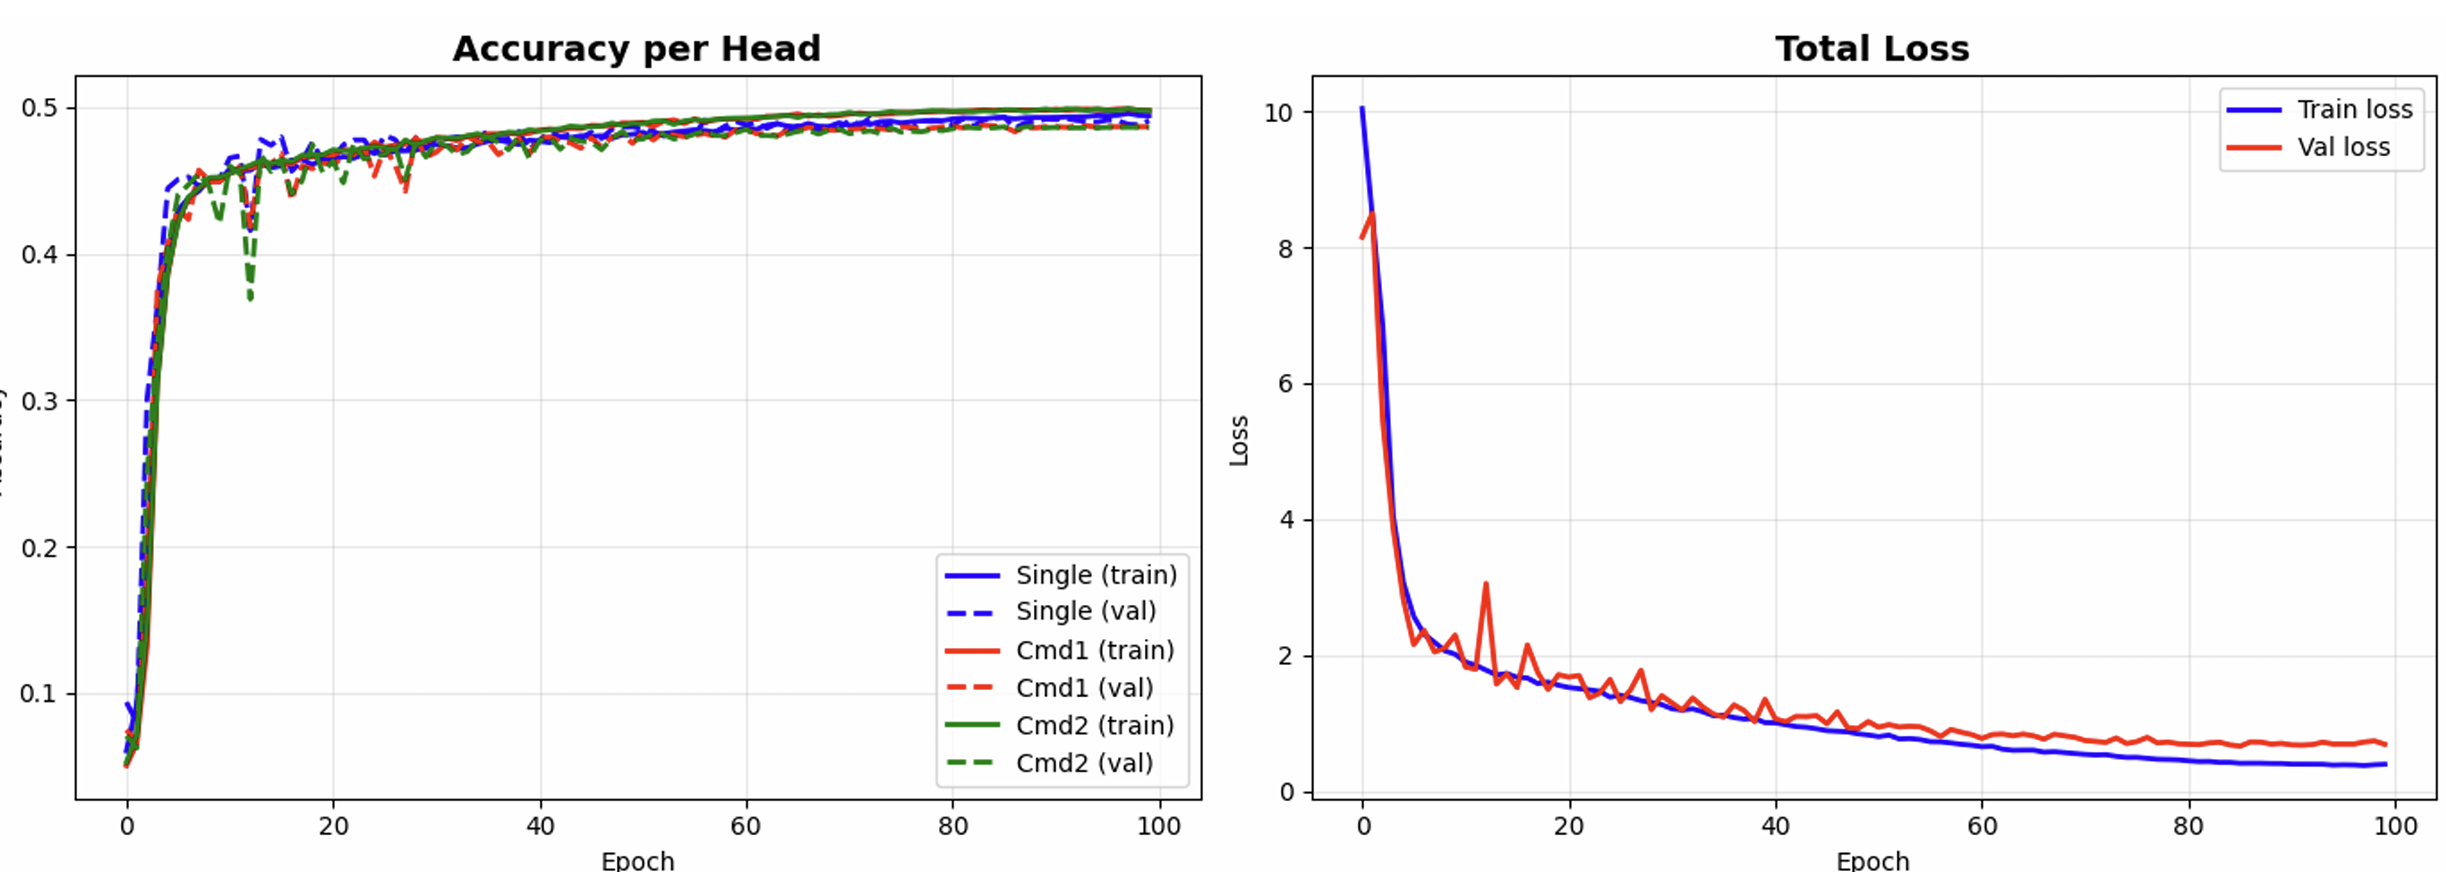

ResNet + Transformer with Noise Mixing
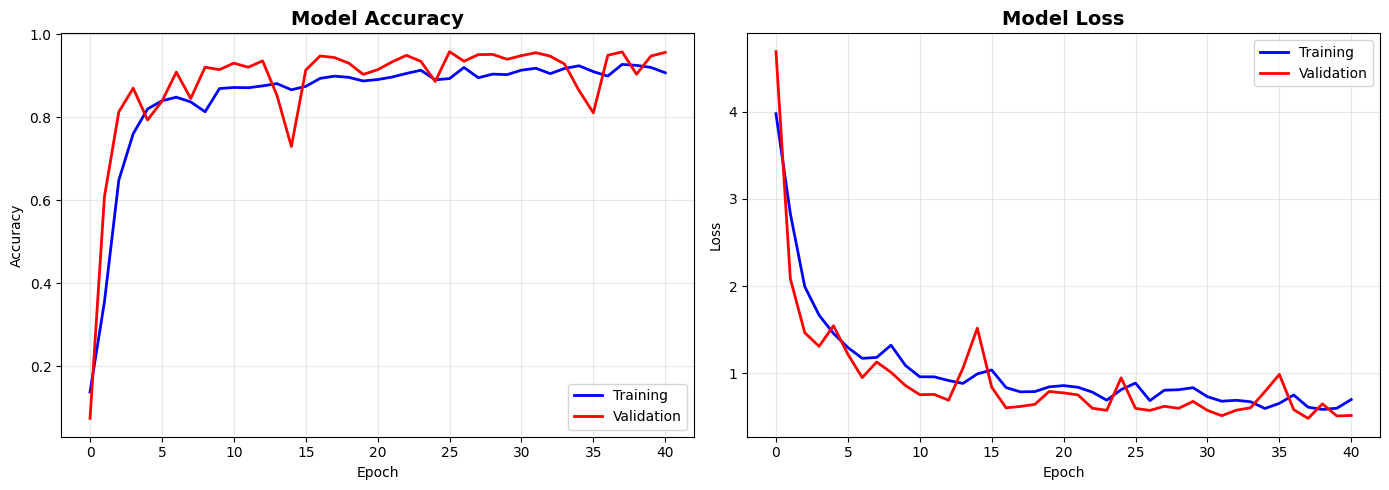

ResNet + Transformer with Noise Mixing and Sequencing
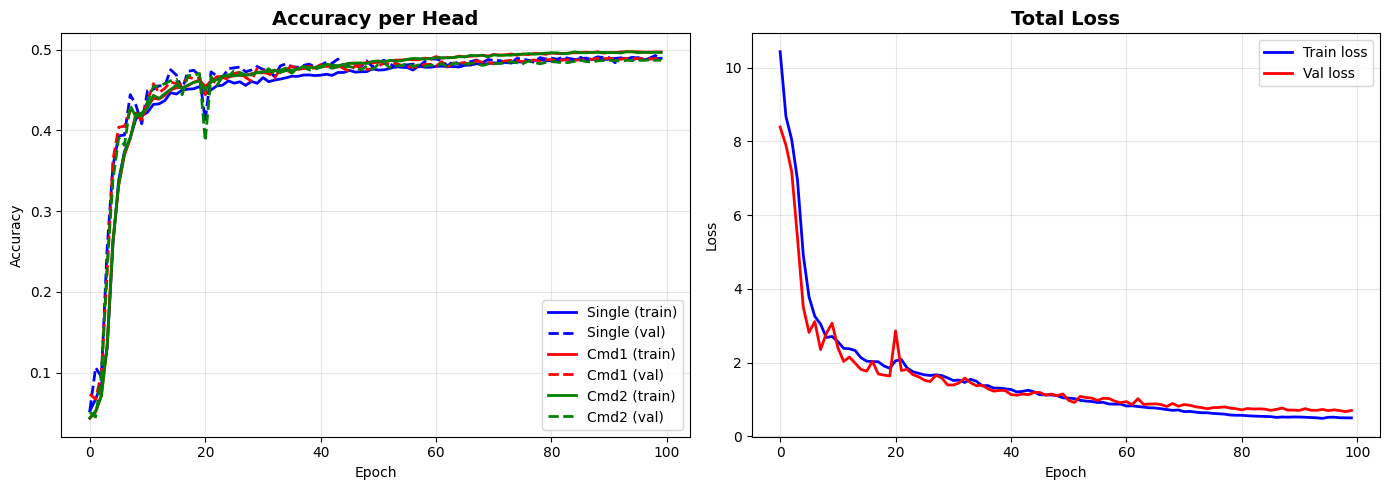

## Results


### Confusion Matrices

ResNet with Noise Mixing

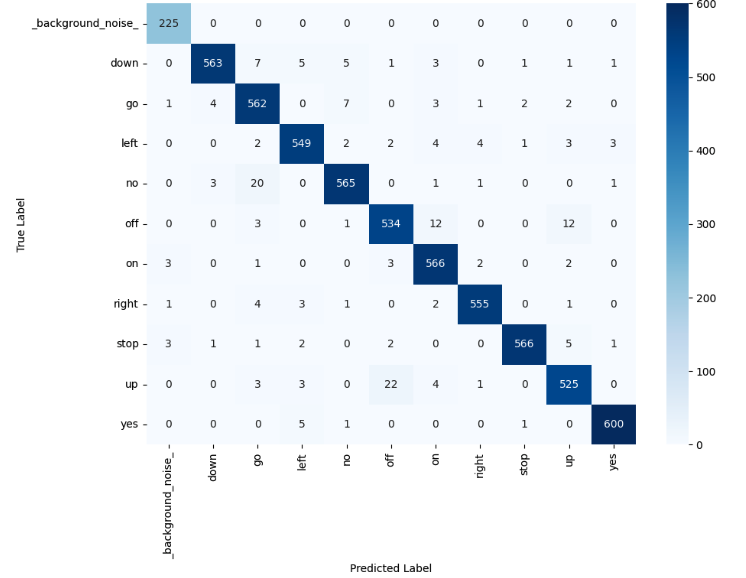

ResNet+Transformer with Noise Mixing
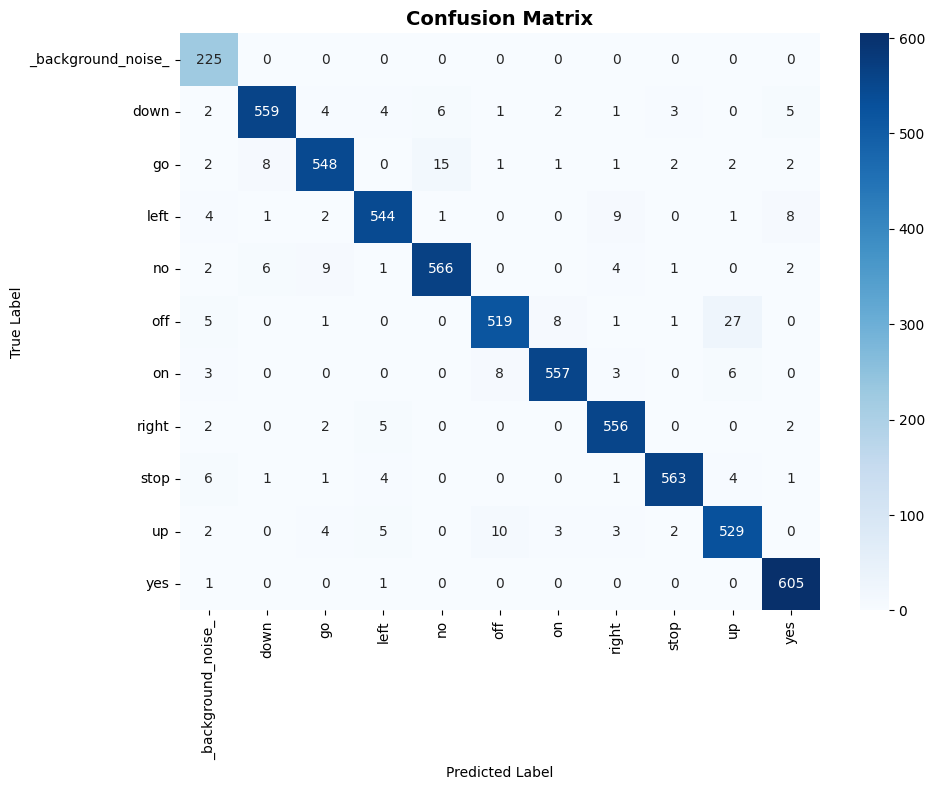

ResNet with Sequencing Confusion Matrix
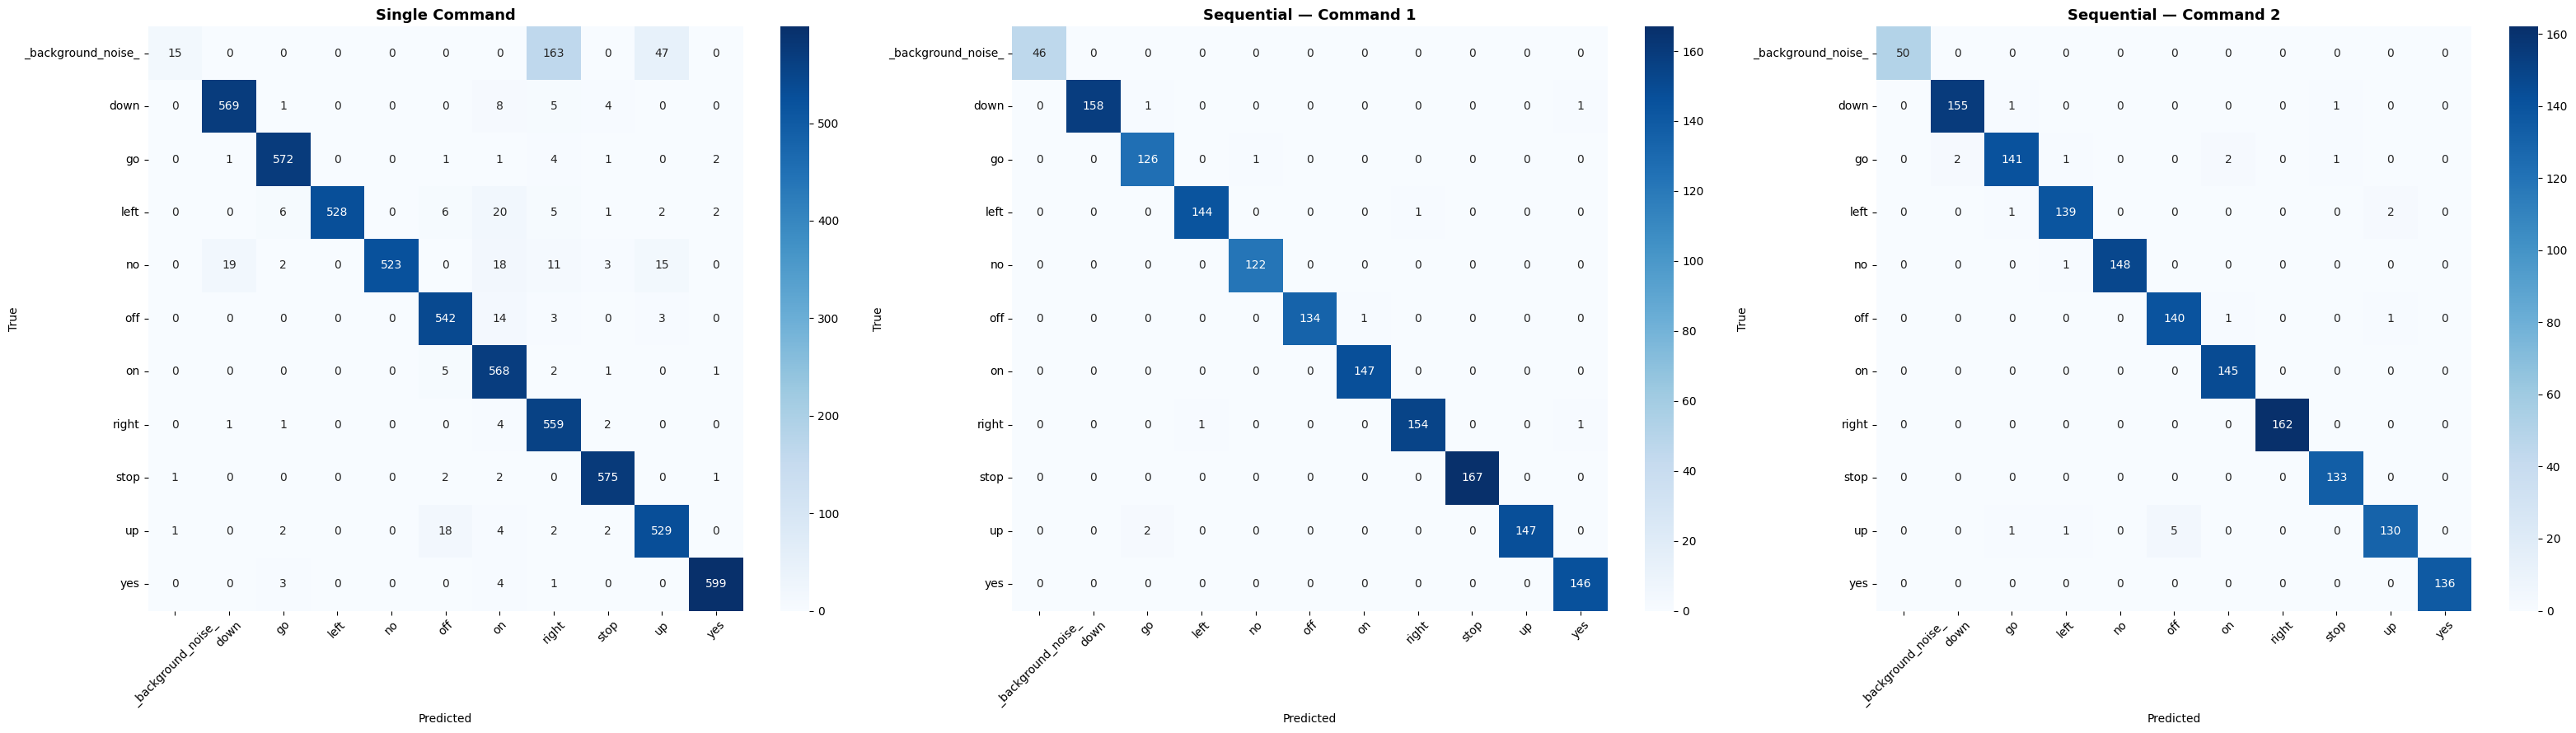

ResNet + Transformer with Sequencing Confusion Matrix
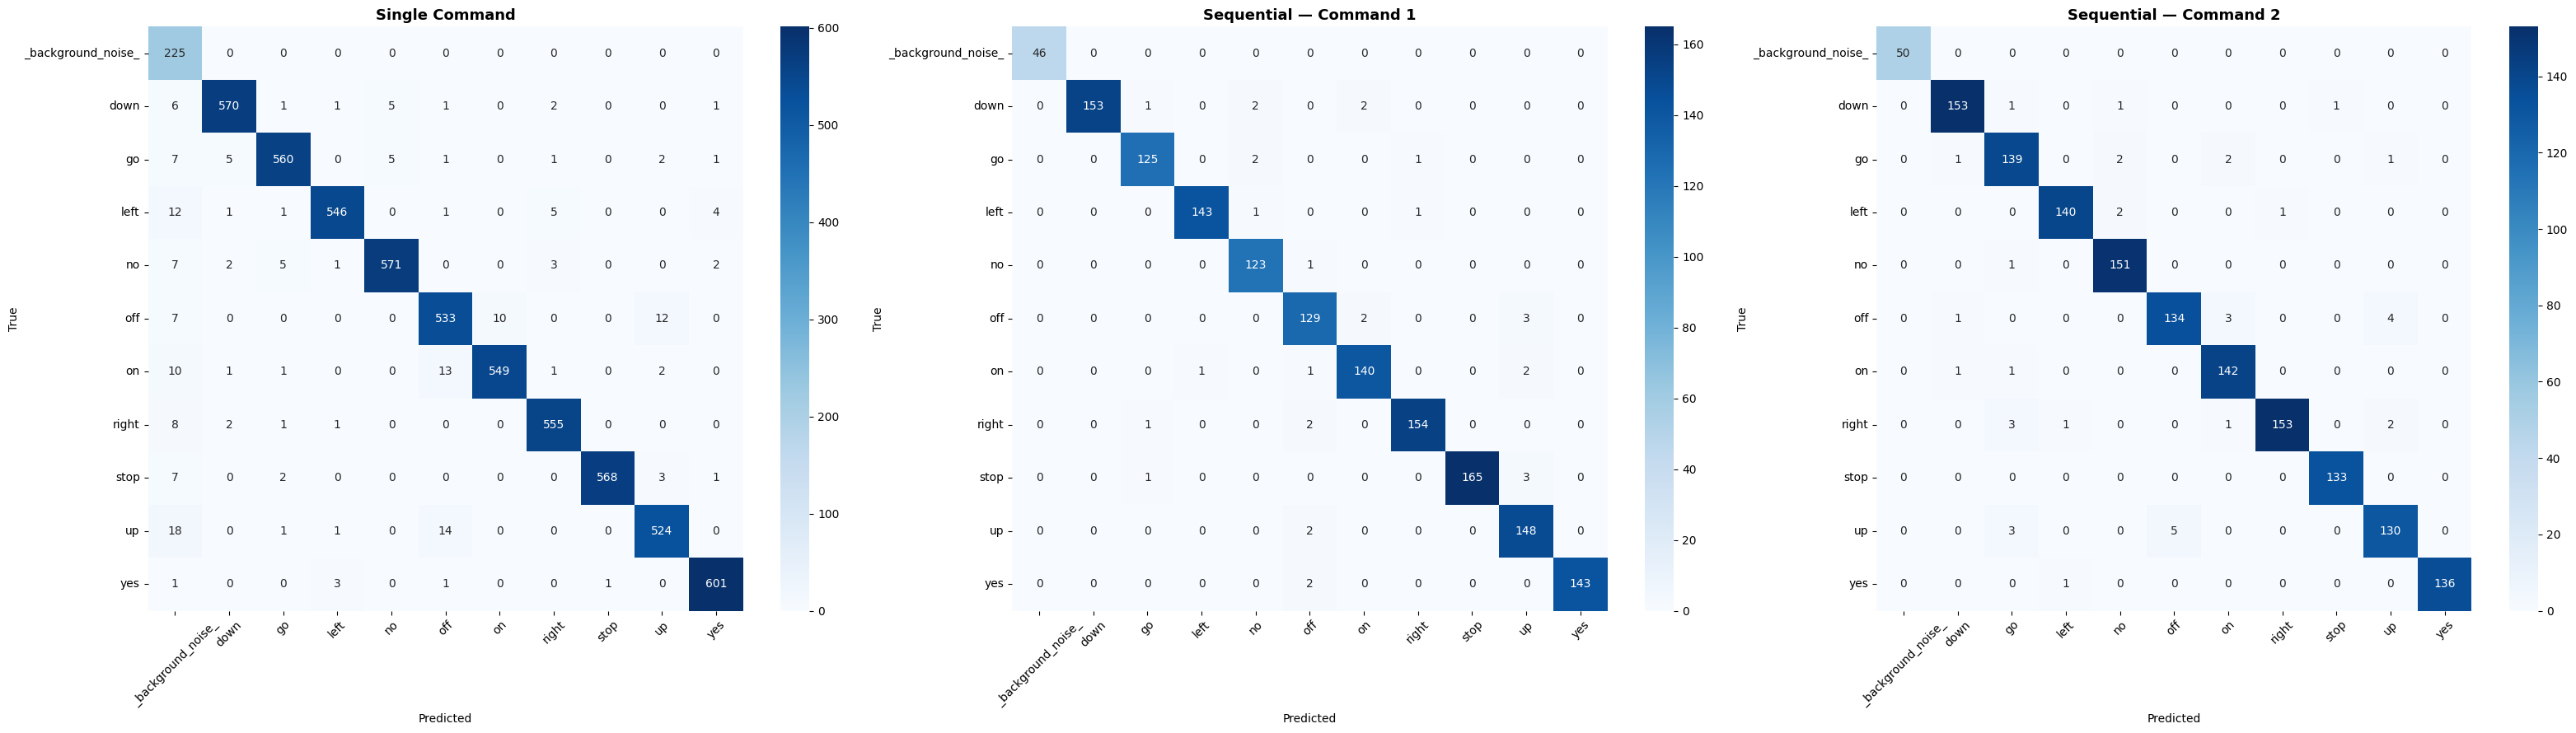

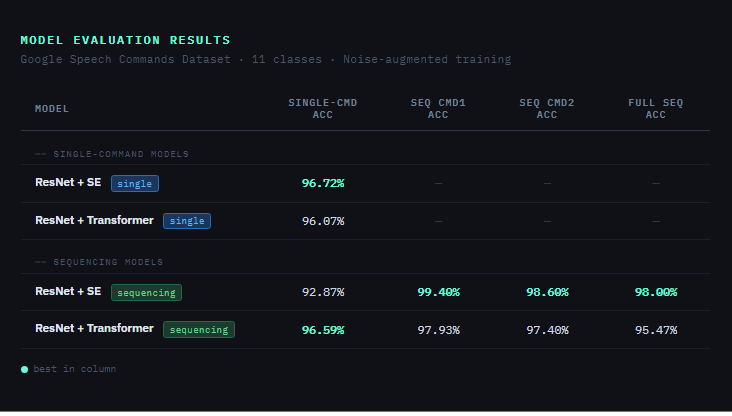

### Demo Game
To deploy our model, we created a simple game that requires speech command inputs to navigate through a max. Here is a [video run through of the game](https://youtu.be/RRiJafNKU-Q?si=qyz52ZtA7kJhOmBw). The ResNet model trained under sequencing and noise was used to predict commands in the game in this video.

###Analysis

**Confusion Matrices**: The confusion matrices come from our test dataset. Based on these matrices, all 4 models performed pretty well even with noise and sequencing. This means that our model generalizes well and is very robust.

**Test Accuracy**: The table shows the test_accuracy for the 4 models. The 2 types of models performed well, but surprisingly the ResNet+Transformer performed worse than the ResNet in sequencing and single-command. Our assumption is that the task is just not complex enough for a transformer to have any sort of impact. In addition, the self attention blocks for the resnet help greatly for sequencing and minimizes the difference between the two models.

**Game demo**: The game demo worked well. There were occasional issues where the character would not recognize the command and not move, but it worked well overall. Latency and response time are pretty hard to visualize, but it looked like it had a good response time to the commands.

###Overfitting vs Underfitting

The models showed mild signs of overfitting rather than underfitting based on the train/validation accuracy gap. The ResNet-Transformer's higher test loss (0.5796) relative to its test accuracy (96.07%) compared to the ResNet (loss 0.3376, accuracy 96.72%) suggests the ResNet-Transformer is less well-calibrated — it is making correct predictions but with lower confidence, which is a soft sign of overfitting. There is no clear sign of underfitting.

###How we combatted overfitting/underfitting
**Dropout** — applied progressively through the convolutional stages (0.10 → 0.30) and aggressively before the dense classifier layers (0.5 then 0.3). This forces the network to not rely on any single feature or pathway, improving generalization. The progressive schedule means earlier layers — which learn low-level features shared across many classes — are regularized lightly, while deeper layers that learn task-specific representations are regularized more heavily.

**L2 regularization** — applied with weight 1e-4 to all Conv2D and Dense layers. This penalizes large weights and prevents the model from fitting sharp, high-variance decision boundaries that don't generalize.
SpecAugment — by randomly masking frequency bands and time regions in the spectrogram during training, the model is prevented from relying on any single frequency channel or time region to identify a command. This directly addresses the risk of overfitting to the specific acoustic fingerprint of training samples.

**Noise mixing augmentation** — mixing background noise at 10dB SNR during training forces the model to learn command features that are robust to environmental interference, rather than fitting to the clean signal characteristics of the training recordings.

**Early stopping with patience 15** — training is halted when validation loss (for sequencing models) or validation accuracy (for single-command models) stops improving, and the best weights are restored. This prevents the model from continuing to minimize training loss past the point of optimal generalization.

**Cosine decay learning rate with warmup** — the learning rate schedule prevents the optimizer from making large destabilizing updates early in training and gradually reduces the step size as training progresses, allowing the model to settle into a flat, generalizable minimum rather than a sharp one that overfits.


###What this says about our data
The high accuracy across all models — both ResNet and CNN-Transformer exceeding 96% on single-command classification — tells us that the Google Speech Commands dataset is relatively clean and well-structured. The log-Mel spectrogram features are highly discriminative for this command set, meaning the 10 commands are acoustically distinct enough that even a moderately complex model can separate them reliably under noise. The consistent pattern of "up," "off," and "go" being the weakest classes across both models is informative — these are short, vowel-heavy monosyllables that share overlapping frequency profiles, suggesting the dataset itself contains genuine acoustic ambiguity between these specific words rather than the models simply failing to generalize.


The near-perfect performance of the sequential heads (98–99%) compared to the single-command heads (93–97%) is also revealing about the data. The synthetic sequences were generated by concatenating two real samples with a silence gap, so the sequential spectrograms are essentially two clean single-command spectrograms joined together. This means the sequential task, while structurally harder, actually contains cleaner and more separable signal per command region than the mixed-noise single-command samples — which explains the paradoxically higher accuracy.

###How would it perform with different data
**Different speakers and accents** — the dataset contains many speakers but was collected under relatively controlled conditions. Speakers with strong accents, unusual prosody, or non-native pronunciation of commands like "go" or "no" would likely cause more confusion between acoustically similar classes, since the model has learned a relatively narrow phonetic distribution.


**Different microphones and recording environments** — the noise augmentation at 10dB SNR teaches the model to handle moderate background noise, but real environments introduce reverberation, microphone frequency response differences, and non-stationary noise (e.g. music, crowds) that differ fundamentally from the additive white-noise-like clips used in training. The maze game live testing is the most direct window into this — any degradation seen there relative to the test set results reflects this distribution shift.


**Continuous natural speech** — the models were trained on isolated 1-second clips and synthetic 2-command sequences with clean silence gaps. In real use, commands might be spoken with variable timing, run-on speech between commands, or filler words. The silence gap detector implicit in the sequential architecture assumes clean segmentation, which real audio rarely provides.

# Discussion

## What you've learned

*Note: you don't have to answer all of these, and you can answer other questions if you'd like. We just want you to demonstrate what you've learned from the project.*

**What concepts from lecture/breakout were most relevant to your project? How so?**

CNNs were most relevant because all our models were CNN models to work with spectrograms.

**What aspects of your project did you find most surprising?**

The similarities in accuracy between the models.

**What lessons did you take from this project that you want to remember for the next ML project you work on? Do you think those lessons would transfer to other datasets and/or models? Why or why not?**

Preprocessing your dataset is very important, and we think this idea would always transfer to other datasets and models.

**What was the most helpful feedback you received during your presentation? Why?**

We didn't receive any feedback.

**If you had two more weeks to work on this project, what would you do next? Why?**
Apply it towards real life applications like an audio controlled wheelchair.